<img src='WhatsApp Image 2026-09-27 at 09.37.53.jpeg'>


<img src='Screenshot 2026-09-27 094109.png'>
<img src='Screenshot 2026-09-27 094620.png'>

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [87]:
customers = pd.read_csv('retail_customers - retail_customers.csv')

print('Rows, columns:', customers.shape)
print('missing values:', int(customers.isna().sum().sum()))
print()
customers.head()

Rows, columns: (1200, 8)
missing values: 0



,customer_id,age,annual_income,visits_last_year,avg_order_value,days_since_purchase,online_order_share,promo_emails_opened
0,10001,37,29280,29,47.41,1,0.29,11
1,10002,31,47698,19,46.79,20,0.46,14
2,10003,39,32533,26,28.41,21,0.44,10
3,10004,27,70006,23,33.72,11,0.51,12
4,10005,38,55755,37,33.94,10,0.35,13


In [88]:
FEATURES = [
    'visits_last_year',
    'avg_order_value',
    'days_since_purchase',
    'online_order_share',
    'promo_emails_opened'
]

X = customers[FEATURES].copy()
X.std().round(3)

visits_last_year        10.363
avg_order_value        116.838
days_since_purchase    104.542
online_order_share       0.199
promo_emails_opened      4.574
dtype: float64

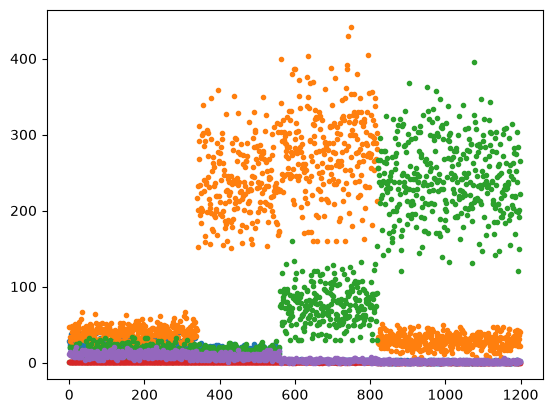

In [89]:
plt.plot(X, ls='', marker='.')

In [90]:
X_train, X_holdout = train_test_split(X, test_size=0.25, random_state=42)

print("Train rows:", len(X_train))
print('hold-out rows:', len(X_holdout))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_holdout_scaled = scaler.transform(X_holdout)

Train rows: 900
hold-out rows: 300


In [91]:
k_values = range(2,9)
rows = []

for k in k_values:
    model = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    model.fit(X_train_scaled)
    #print(model.cluster_centers_)
    train_mean_wcss = model.inertia_ / len(X_train_scaled)
    print(f'{k}: train_mean_wcss: {train_mean_wcss}')
    _, holdout_dist = pairwise_distances_argmin_min(X_holdout_scaled, model.cluster_centers_)
    holdout_mean_wcss = float((holdout_dist**2).mean())
    print(f'{k}: holdout_mean_wcss: {holdout_mean_wcss}')


    silhouette = silhouette_score(X_train_scaled, model.labels_)
    print(f'{k}: silhoutte: {silhouette}')

    print('-'*50)

    rows.append({
        'k':k,
        'train_mean_wcss':train_mean_wcss,
        'holdout_mean_wcss':holdout_mean_wcss,
        'silhouette':silhouette,
        'iterations':model.n_iter_
    })

print(rows)
k_report = pd.DataFrame(rows)
k_report.round(3)


2: train_mean_wcss: 2.421539344757035
2: holdout_mean_wcss: 2.295458339293949
2: silhoutte: 0.46524074267079263
--------------------------------------------------
3: train_mean_wcss: 1.3654932657115322
3: holdout_mean_wcss: 1.3427720600265964
3: silhoutte: 0.5089035358681604
--------------------------------------------------
4: train_mean_wcss: 0.8964343224436558
4: holdout_mean_wcss: 0.880791800183701
4: silhoutte: 0.5196244617142175
--------------------------------------------------
5: train_mean_wcss: 0.8158674735583786
5: holdout_mean_wcss: 0.7971256288704878
5: silhoutte: 0.4566552961424711
--------------------------------------------------
6: train_mean_wcss: 0.7468116968591111
6: holdout_mean_wcss: 0.741348993752259
6: silhoutte: 0.3992575254088744
--------------------------------------------------
7: train_mean_wcss: 0.6720073929296673
7: holdout_mean_wcss: 0.6629976101158856
7: silhoutte: 0.2974997158449563
--------------------------------------------------
8: train_mean_wcss:

,k,train_mean_wcss,holdout_mean_wcss,silhouette,iterations
0,2,2.422,2.295,0.465,5
1,3,1.365,1.343,0.509,6
2,4,0.896,0.881,0.520,6
3,5,0.816,0.797,0.457,27
4,6,0.747,0.741,0.399,18
5,7,0.672,0.663,0.297,11
6,8,0.627,0.612,0.273,10


n_init ====> First random centroid is selected from randomly selecting the centroid and calculate its wcss then it do it again n_init times and get the better random centroid from smaller value wcss centroid. 

model.inertia_ ===> Gives the wcss value.<br>
silhouette_score ===> Gives the seperation of cluster.1 is better seperation.

model.labels_ ===> Gives the data points cluster number(0,1,2,3,4,..)

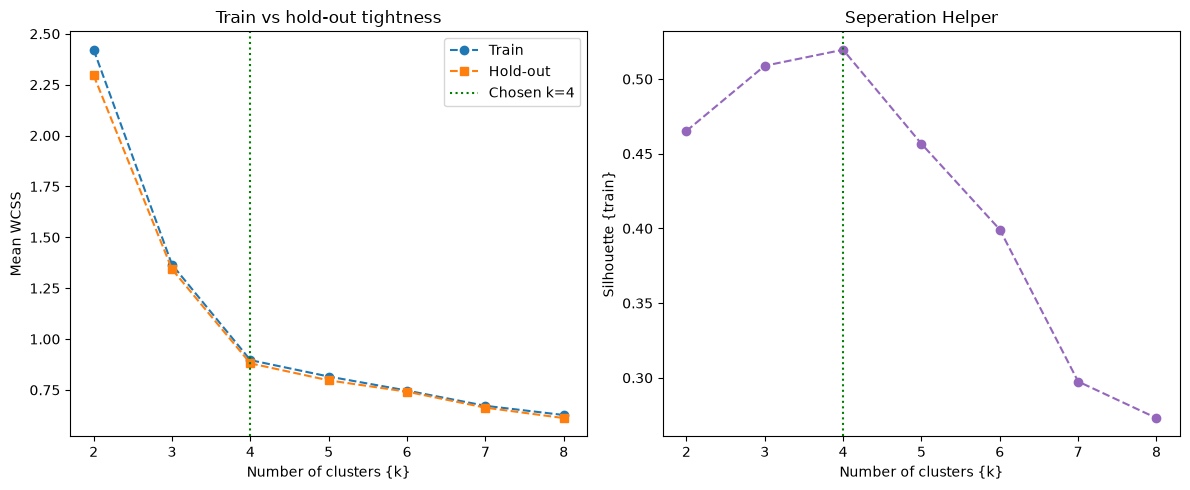

In [92]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].plot(k_report['k'], k_report['train_mean_wcss'], 'o--', label='Train')
ax[0].plot(k_report['k'], k_report['holdout_mean_wcss'], 's--', label='Hold-out')
ax[0].axvline(4, color='green', ls=':', label='Chosen k=4')
ax[0].set_xlabel('Number of clusters {k}')
ax[0].set_ylabel('Mean WCSS')
ax[0].set_title('Train vs hold-out tightness')
ax[0].set_xticks(list(k_values))
ax[0].legend()

ax[1].plot(k_report['k'], k_report['silhouette'], 'o--', color='tab:purple')
ax[1].axvline(4, color='green', ls=':')
ax[1].set_xlabel('Number of clusters {k}')
ax[1].set_ylabel('Silhouette {train}')
ax[1].set_title('Seperation Helper')
ax[1].set_xticks(list(k_values))

fig.tight_layout()
plt.show()


In [93]:
CHOSEN_K = 4

production_scaler = StandardScaler()
X_scaled = production_scaler.fit_transform(X)

kmeans = KMeans(
    n_clusters=4,
    init='k-means++',
    n_init=10,
    random_state=42
)

kmeans.fit(X_scaled)
print('Iterations to converge:', kmeans.n_iter_)
print('inertia (WCSS) on all customers:', round(kmeans.inertia_, 1))
print("Mean WCSS:", round(kmeans.inertia_ / len(X_scaled), 3))

Iterations to converge: 4
inertia (WCSS) on all customers: 1068.1
Mean WCSS: 0.89


In [94]:
new_customer = pd.DataFrame([{
    'visits_last_year': 3,
    'avg_order_value': 310.0,
    'days_since_purchase': 80,
    'online_order_share': 0.30,
    'promo_emails_opened': 2,
}])

In [96]:
new_customer_scaled = production_scaler.transform(new_customer[FEATURES])
new_cluster = kmeans.predict(new_customer_scaled)[0]

print('Cluster id:', new_cluster)

Cluster id: 3
